In [1]:
# download cCRE input
download.file("https://downloads.wenglab.org/GRCh38-cCREs.CTCF-bound.bed", destfile = "./GRCh38-cCREs.CTCF-bound.bed")
download.file("https://downloads.wenglab.org/Registry-V4/ENCFF439DDQ_ENCFF885SUR_ENCFF128UTY.bed", destfile = "./SCREEN-293-cCRE-ENCFF439DDQ_ENCFF885SUR_ENCFF128UTY.bed")
download.file("https://downloads.wenglab.org/Registry-V4/SCREEN/Signal-Files/ENCSR000DTW-ENCFF128UTY.tsv", destfile = "SCREEN-293-CTCFzscore-ENCSR000DTW-ENCFF128UTY.tsv")
download.file("https://downloads.wenglab.org/Registry-V4/ENCFF529BOG.bed",destfile = "SCREEN-293T-cCRE-ENCFF529BOG.bed")


In [2]:
# install packages if needed
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
BiocManager::install("GenomicRanges", ask = FALSE)
BiocManager::install("rtracklayer", ask = FALSE)

Bioconductor version '3.22' is out-of-date; the current release version '3.23'
  is available with R version '4.6'; see https://bioconductor.org/install

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'GenomicRanges'”
Old packages: 'devtools', 'fs'

Warning message in install.packages(update[instlib == l, "Package"], l, contriburl = contriburl, :
“installation of package ‘fs’ had non-zero exit status”
Warning message in install.packages(update[instlib == l, "Package"], l, contriburl = contriburl, :
“installation of package ‘devtools’ had non-zero exit status”
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories

In [3]:
# library
library("dplyr")
library("Matrix")
library("ggplot2")
library("stringi")
library("GenomicRanges")
library("rtracklayer")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:dplyr’:

    combine


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply,

In [4]:
# input matrix
load("./CTCF_bin1000_mtx.rds")
raw_counts <- CTCF_bin1000_mtx
CTCF_data_df <- data.frame(bin_name=rownames(raw_counts))
CTCF_parts <- stri_split_regex(CTCF_data_df$bin_name, pattern = ":|-", simplify = TRUE)
CTCF_bins_gr_raw <- GRanges(seqnames = CTCF_parts[,1], ranges = IRanges(start = as.numeric(CTCF_parts[,2]) + 1, end = as.numeric(CTCF_parts[,3])))

In [7]:
# filter blacklist
download.file("https://github.com/Boyle-Lab/Blacklist/raw/refs/heads/master/lists/hg38-blacklist.v2.bed.gz", destfile = "hg38-blacklist.v2.bed.gz")
blacklist_gr <- import.bed("hg38-blacklist.v2.bed.gz")
blacklist_overlaps <- findOverlaps(CTCF_bins_gr_raw, blacklist_gr)
blacklist_indices <- unique(queryHits(blacklist_overlaps))
raw_counts_rmblacklist <- raw_counts[-blacklist_indices, ]
print(length(blacklist_indices))
CTCF_bins_gr <- CTCF_bins_gr_raw[-blacklist_indices,]

[1] 195818


In [9]:
# generate positive CTCF cCRE
CTCF_293_cCRE <- read.table("SCREEN-293-CTCFzscore-ENCSR000DTW-ENCFF128UTY.tsv", sep="\t", stringsAsFactors=FALSE) %>% dplyr::rename(cCRE=V1, score=V2)
bed_293_cCRE <- read.table("SCREEN-293-cCRE-ENCFF439DDQ_ENCFF885SUR_ENCFF128UTY.bed", sep="\t", stringsAsFactors=FALSE) %>% dplyr::rename(chrom=V1, start=V2, end=V3, cCRE=V4, class=V10)
bed_293_cCRE %>% left_join(CTCF_293_cCRE, by="cCRE") -> bed_293_CTCF_cCRE
bed_293_CTCF_cCRE %>% filter(grepl("CTCF", class)) -> bed_293_CTCF_cCRE_filtered
bed_293T_cCRE <- read.table("SCREEN-293T-cCRE-ENCFF529BOG.bed", sep="\t", stringsAsFactors=FALSE) %>% dplyr::rename(chrom=V1, start=V2, end=V3, cCRE=V4, class=V10)
bed_293T_cCRE %>% filter(grepl("CA", class)) -> bed_293T_cCRE_filtered
bed_293_CTCF_cCRE_filtered %>% filter(cCRE %in% bed_293T_cCRE_filtered$cCRE) -> bed_293_CTCF_cCRE_filtered_293T
bed_293_CTCF_cCRE_filtered_293T %>% arrange(desc(score)) %>% head(10000) -> CTCF_cCRE_top10K
CTCF_top10K_gr <- GRanges(seqnames = CTCF_cCRE_top10K[,1], ranges = IRanges(start = as.numeric(CTCF_cCRE_top10K[,2]), end = as.numeric(CTCF_cCRE_top10K[,3])))
hits_top10K <- findOverlaps(CTCF_bins_gr, CTCF_top10K_gr)
pos_idx <- unique(queryHits(hits_top10K))

In [10]:
# generate negative CTCF cCRE
CTCF_bound <- read.table("GRCh38-cCREs.CTCF-bound.bed", sep="\t", stringsAsFactors=FALSE) %>% dplyr::rename(chrom=V1, start=V2, end=V3, cCRE=V5, class=V6)
CTCF_bound_gr <- GRanges(seqnames = CTCF_bound[,1], ranges = IRanges(start = as.numeric(CTCF_bound[,2]), end = as.numeric(CTCF_bound[,3])))
hits_bound <- findOverlaps(CTCF_bins_gr, CTCF_bound_gr)
nonneg_idx <- unique(queryHits(hits_bound))
all_idx <- 1:length(CTCF_bins_gr)
potential_neg_idx <- setdiff(all_idx, nonneg_idx)
set.seed(2026)
neg_idx <- sample(potential_neg_idx, size = length(pos_idx))

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


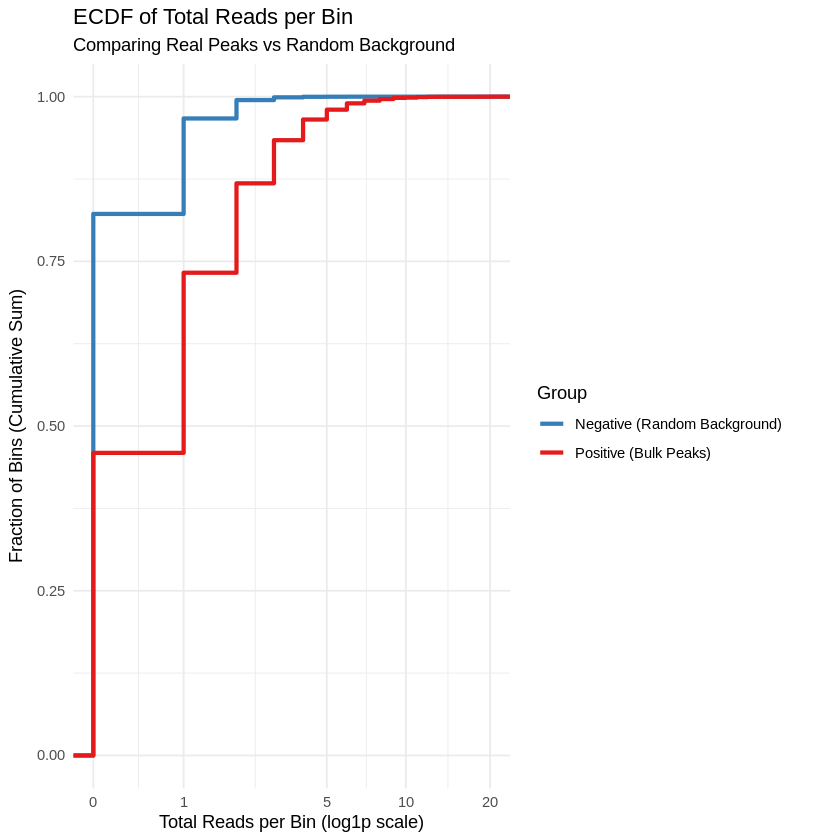

In [11]:
# compare positive and negative bins
pos_totals <- Matrix::rowSums(raw_counts_rmblacklist[pos_idx, ])
neg_totals <- Matrix::rowSums(raw_counts_rmblacklist[neg_idx, ])

df_ecdf <- rbind(
  data.frame(counts = pos_totals, Group = "Positive (Bulk Peaks)"),
  data.frame(counts = neg_totals, Group = "Negative (Random Background)")
)

ggplot(df_ecdf, aes(x = counts, color = Group)) +
  stat_ecdf(size = 1.2) +
  scale_x_continuous(trans = "log1p", breaks = c(0, 1, 5, 10, 20, 50, 100)) +
  labs(
    title = "ECDF of Total Reads per Bin",
    subtitle = "Comparing Real Peaks vs Random Background",
    x = "Total Reads per Bin (log1p scale)",
    y = "Fraction of Bins (Cumulative Sum)"
  ) +
  theme_minimal() +
  scale_color_manual(values = c("Positive (Bulk Peaks)" = "#E41A1C", "Negative (Random Background)" = "#377EB8"))
